<a href="https://colab.research.google.com/github/ArkaanHilmiS/RuangGuru_AI/blob/main/Project_1_n8n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 - n8n: Telegram Bot dengan AI Agent (Gemini)

## Deskripsi Project
Dalam project ini, kita akan membuat sebuah Telegram Bot yang menggunakan Google Gemini sebagai AI Agent untuk membalas pesan pengguna secara otomatis dan intelligent.

## Tujuan Pembelajaran
- Memahami cara mengintegrasikan Telegram dengan n8n Cloud
- Menggunakan AI Agent (Google Gemini) dalam workflow
- Membuat chatbot yang responsif dan intelligent

## Tools yang Dibutuhkan
1. **n8n Cloud Account** - Daftar di https://n8n.io/
2. **Telegram Bot Token** - Dari BotFather
3. **Google Gemini API Key** - Dari Google AI Studio


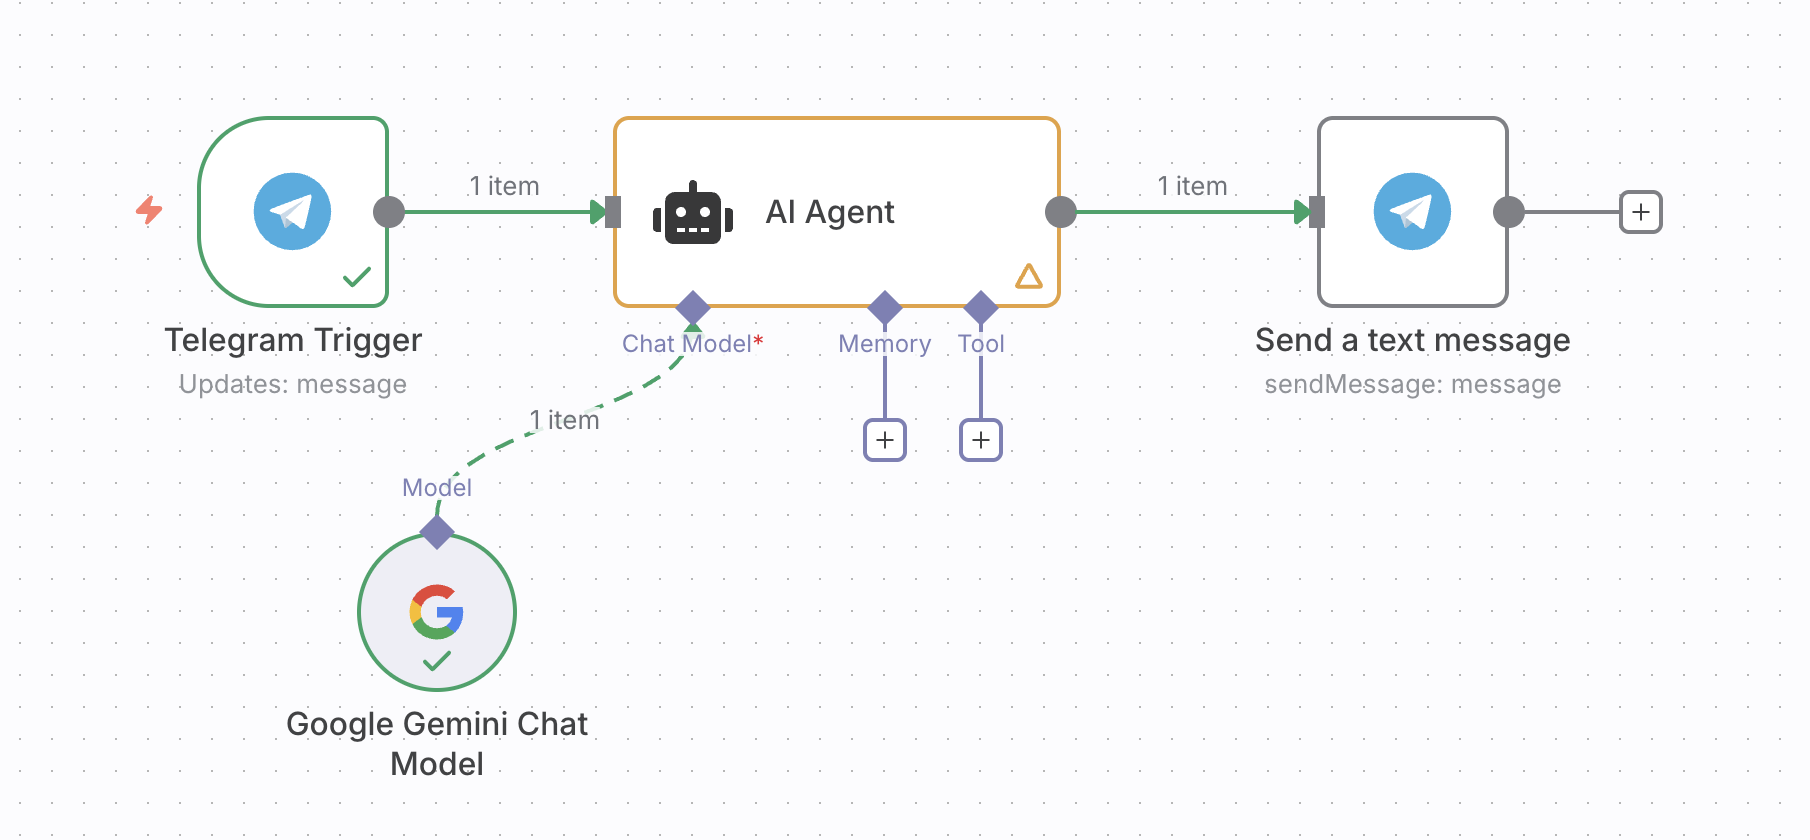

## Langkah 1: Persiapan Telegram Bot

### 1.1 Buat Bot di Telegram

1. Buka Telegram dan cari **@BotFather**
2. Kirim perintah `/newbot`
3. Ikuti instruksi:
   - Masukkan nama bot (contoh: `My AI Assistant`)
   - Masukkan username bot (harus diakhiri dengan `bot`, contoh: `my_ai_assistant_bot`)
4. BotFather akan memberikan **API Token** - simpan token ini!

```
Contoh Token:
1234567890:ABCdefGHIjklMNOpqrsTUVwxyz1234567890
```

### 1.2 Test Bot
- Cari bot Anda di Telegram menggunakan username yang dibuat
- Klik **Start** untuk mengaktifkan bot

---

## Langkah 2: Dapatkan Google Gemini API Key

### 2.1 Akses Google AI Studio

1. Buka [Google AI Studio](https://aistudio.google.com/)
2. Login dengan akun Google Anda
3. Klik **Get API Key**
4. Buat project baru atau pilih project yang ada
5. Klik **Create API Key**
6. Copy API Key yang diberikan

```
Contoh API Key:
AIzaSyD1234567890abcdefghijklmnopqrstuvwx
```

## Langkah 3: Setup n8n Cloud

### 3.1 Buat n8n Cloud Account

1. Buka https://n8n.cloud
2. Klik **Sign Up** atau **Start Free Trial**
3. Daftar menggunakan email atau akun Google
4. Verifikasi email Anda
5. Login ke dashboard n8n Cloud

### 3.2 Buat Workflow Baru

1. Di dashboard n8n Cloud, klik **+ Add Workflow**
2. Beri nama workflow: **Telegram Bot with Gemini**
3. Anda akan diarahkan ke canvas workflow editor

### 3.3 Tambah Node Telegram Trigger

1. Klik tombol **+** di canvas atau tekan **Tab**
2. Cari dan pilih **Telegram Trigger**
3. Pilih **on message**
4. Klik **Create New Credential**
5. Masukkan:
   - **Credential Name**: `Telegram Bot`
   - **Access Token**: Paste token dari BotFather
6. Klik **Save**

### 3.4 Tambah Node AI Agent (Gemini)

1. Klik **+** setelah node Telegram Trigger
2. Cari dan pilih **AI Agent**
3. Di bagian **Text**, masukkan: `={{ $json.message.text }}`
4. Di bagian **System Message**, masukkan:
```
Kamu adalah asisten AI yang ramah dan membantu. Nama kamu adalah AI Assistant.

Tugas kamu:
- Menjawab pertanyaan dengan jelas dan akurat
- Menggunakan bahasa yang sopan dan mudah dipahami
- Jika tidak tahu jawaban, katakan dengan jujur
- Berikan penjelasan yang detail tapi tidak bertele-tele

Bahasa: Gunakan bahasa Indonesia kecuali user meminta bahasa lain.
```
5. Klik **Create New Credential** untuk Gemini
6. Masukkan:
   - **Credential Name**: `Gemini API`
   - **API Key**: Paste API Key dari Google AI Studio
7. Klik **Save**

### 3.5 Tambah Node Telegram Send Message

1. Klik **+** setelah node AI Agent
2. Cari dan pilih **Telegram**
3. Di **Resource**, pilih **Message**
4. Di **Operation**, pilih **Send a Text Message**
5. Di **Chat ID**, masukkan: `{{ $('Telegram Trigger').item.json.message.chat.id }}`
6. Di **Text**, masukkan: `{{ $('AI Agent').item.json.output }}`
7. Gunakan credential Telegram yang sama (sudah tersimpan)
8. Klik **Save**

### 3.6 Simpan Workflow

1. Klik **Save** di kanan atas
2. Workflow Anda sudah siap!

---

## Langkah 4: Download Workflow JSON

Setelah testing berhasil, download workflow untuk submit:

1. Di workflow editor, klik menu **...** (tiga titik) di kanan atas
2. Pilih **Download**
3. File akan ter-download dengan format: `[nama-workflow].json`
4. Simpan file ini untuk di-submit ke RG Grader

## Langkah 5: Submit ke RG Grader

1. Masukkan Nama dan Student ID
2. Upload file JSON workflow yang sudah di-download
3. Klik **Submit**
4. Tunggu hasil grading

**Catatan**: Pastikan workflow sudah di-test dan berfungsi dengan baik sebelum submit!

## Submit Project

In [1]:
%pip install rggrader2

from rggrader import submit

# @title #### Student Identity
student_id = "REAENG11UVKIF"  # @param {type:"string"}
name = "Arkaan Hilmi Suharsoyo"  # @param {type:"string"}
batch = "batch-11" # @param {type:"string"}

In [2]:
from rggrader import submit
from google.colab import files
import json

def extract_node_types(data):
    return [node["type"] for node in data.get("nodes", [])]

uploaded = files.upload()

filename = list(uploaded.keys())[0]

with open(filename, 'r', encoding='utf-8') as f:
    data = json.load(f)

node_types = extract_node_types(data)

json_str = json.dumps(node_types, ensure_ascii=False, indent=2)

assignment_id = "01_project-n8n"
question_id = "01_telegram-bot-gemini"

submit(student_id, name, assignment_id, json_str, batch, question_id)


Saving Telegram Bot with Gemini.json to Telegram Bot with Gemini (1).json


'Assignment successfully submitted. Score: 100'